# 1. Introduction

This project aims to predict the presence of heart disease in patients using clinical measurements and patient demographics. The dataset comprises 920 patient records from multiple sources (Cleveland, Hungary, Switzerland, VA Long Beach) with 16 features including age, blood pressure, cholesterol levels, and ECG results. The target variable 'num' indicates presence of disease (0 = no disease, >1 = disease). By applying supervised and unsupervised machine learning techniques, we aim to build a reliable classifier for early disease detection and risk assessment.

# 2. Dataset Description

In [832]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [833]:
dataset = pd.read_csv('Dataset/8.csv')
display(dataset)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [834]:
print(f"Dataset Shape: {dataset.shape}")
print(f"\nFeature Types:")
print(dataset.dtypes)
print(f"\nMissing Values:")
display(dataset.isnull().sum())

Dataset Shape: (920, 16)

Feature Types:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Missing Values:


id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

The dataset contains 920 data points, and 16 features:

**Numeric Features:** id, age, trestbps, chol, thalch, oldpeak, ca, num

**Categorical Features:** sex, dataset, cp, fbs, restecg, exang, slope, thal

**Target Variable:** num (0 = no disease, 1-4 = severity levels)

# 3. Data Analysis

In [835]:
numerical_data = dataset.select_dtypes(include='number')
numerical_features = numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:')
print(numerical_features, "\n")

categorical_data = dataset.select_dtypes(include='object')
categorical_features = categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:')
print(categorical_features)

There are 8 numerical features:
['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'] 

There are 8 categorical features:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


### Variance and Skew

The variance analysis shows all features have sufficient variation to be informative. Several features exhibit skewness (oldpeak, ca), but we address this through outlier capping and column dropping rather than transformation, as our ensemble methods are invariant to skewness.

In [836]:
display(numerical_data.var())
display(categorical_data.describe().T)

id          70610.000000
age            88.824691
trestbps      363.515007
chol        12272.387943
thalch        672.171813
oldpeak         1.190775
ca              0.875447
num             1.305748
dtype: float64

,count,unique,top,freq
sex,920,2,Male,726
dataset,920,4,Cleveland,304
cp,920,4,asymptomatic,496
fbs,830,2,False,692
restecg,918,3,normal,551
exang,865,2,False,528
slope,611,3,flat,345
thal,434,3,normal,196


In [837]:
numerical_data.skew()

id          0.000000
age        -0.195994
trestbps    0.213334
chol       -0.613836
thalch     -0.211119
oldpeak     1.041427
ca          1.165978
num         0.968880
dtype: float64

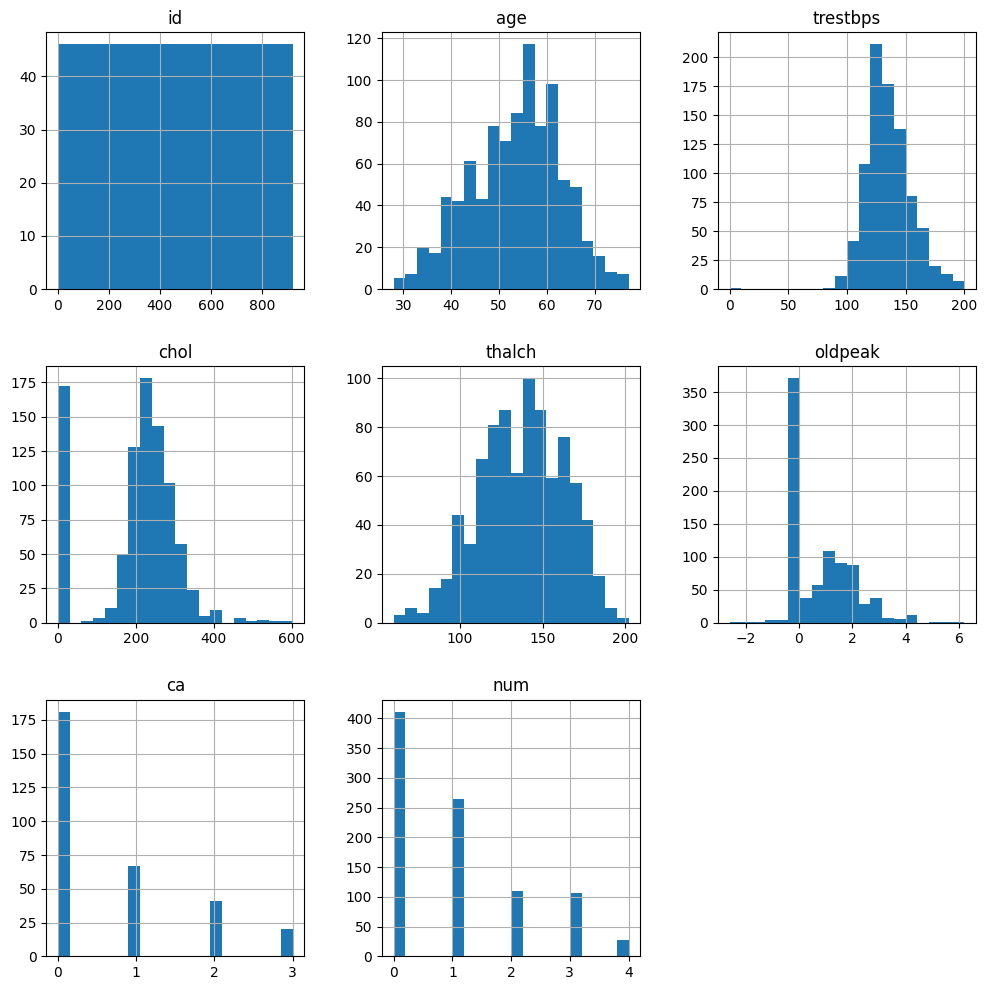

In [838]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

### Outlier Detection

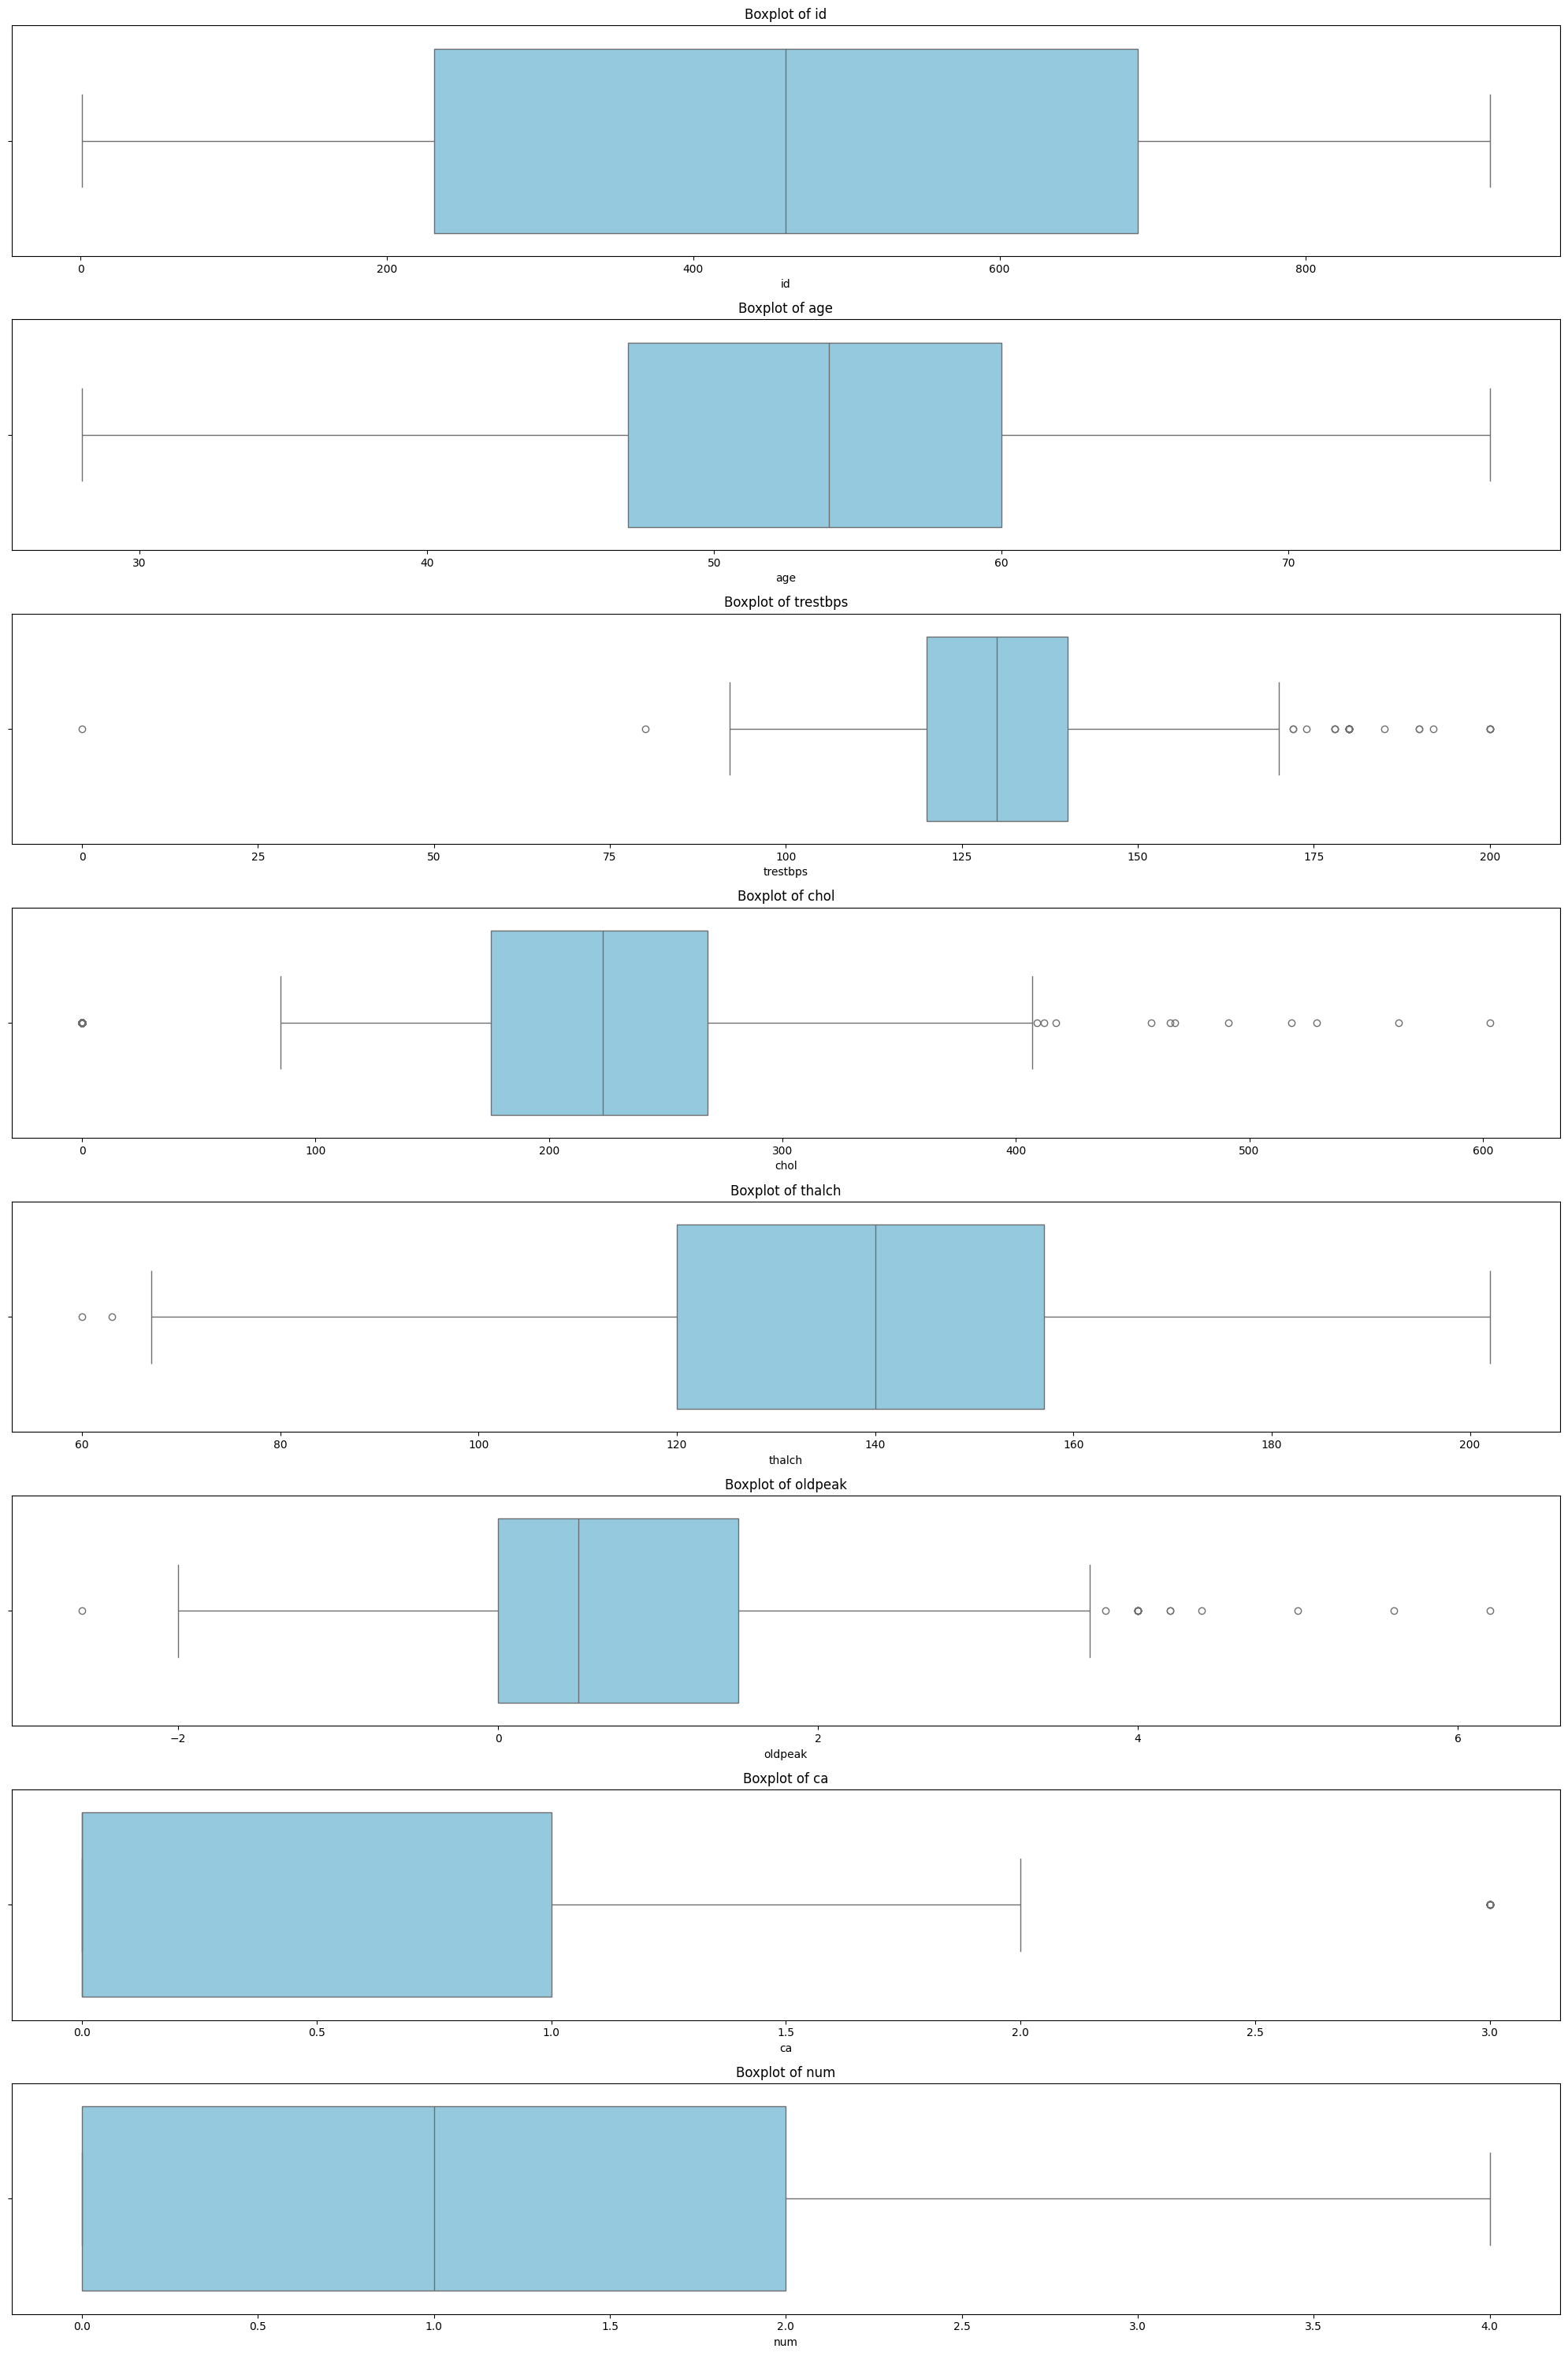

In [839]:
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 30))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

### Correlation Heatmap

,id,age,trestbps,chol,thalch,oldpeak,ca,num
id,1.000000,0.239301,0.052924,-0.376936,-0.466427,0.049930,0.061433,0.273552
age,0.239301,1.000000,0.244253,-0.086234,-0.365778,0.258243,0.370416,0.339596
trestbps,0.052924,0.244253,1.000000,0.092853,-0.104899,0.161908,0.093705,0.122291
chol,-0.376936,-0.086234,0.092853,1.000000,0.236121,0.047734,0.051606,-0.231547
thalch,-0.466427,-0.365778,-0.104899,0.236121,1.000000,-0.151174,-0.264094,-0.366265
oldpeak,0.049930,0.258243,0.161908,0.047734,-0.151174,1.000000,0.281817,0.443084
ca,0.061433,0.370416,0.093705,0.051606,-0.264094,0.281817,1.000000,0.516216
num,0.273552,0.339596,0.122291,-0.231547,-0.366265,0.443084,0.516216,1.000000


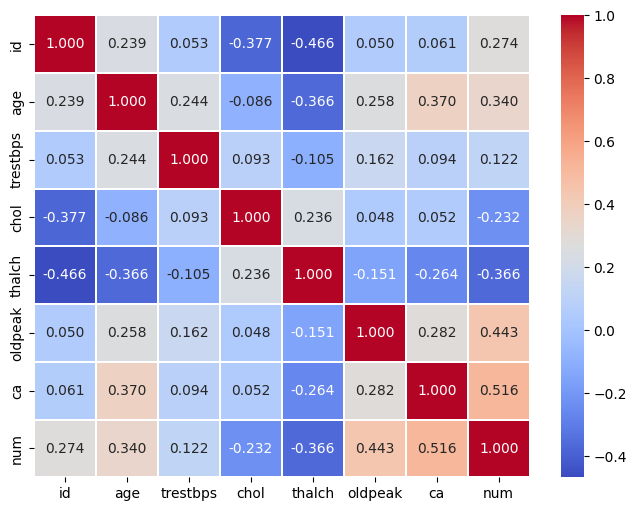

In [840]:
correlation_matrix = numerical_data.corr()
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

### Correlation Analysis

We compute correlation using three different methods (Pearson, Spearman, Kendall) to understand both linear and non-linear relationships between features and the target variable. 

**Key Observations:**
- **Pearson**: Measures linear correlation. Strong predictors like `cp` (chest pain type), `thalch` (max heart rate), and `exang` (exercise-induced angina) show consistent correlation across methods.
- **Spearman/Kendall**: Capture monotonic (non-linear) relationships. These methods are robust to outliers and better suited for ordinal features.
- **Feature Selection Insight**: Features with consistently high correlation across all three methods (e.g., `cp`, `thalch`, `oldpeak`) are reliable predictors and were retained. Low-correlation features like `trestbps` (resting blood pressure) show weak predictive power but are kept as they may interact with other features in ensemble models.

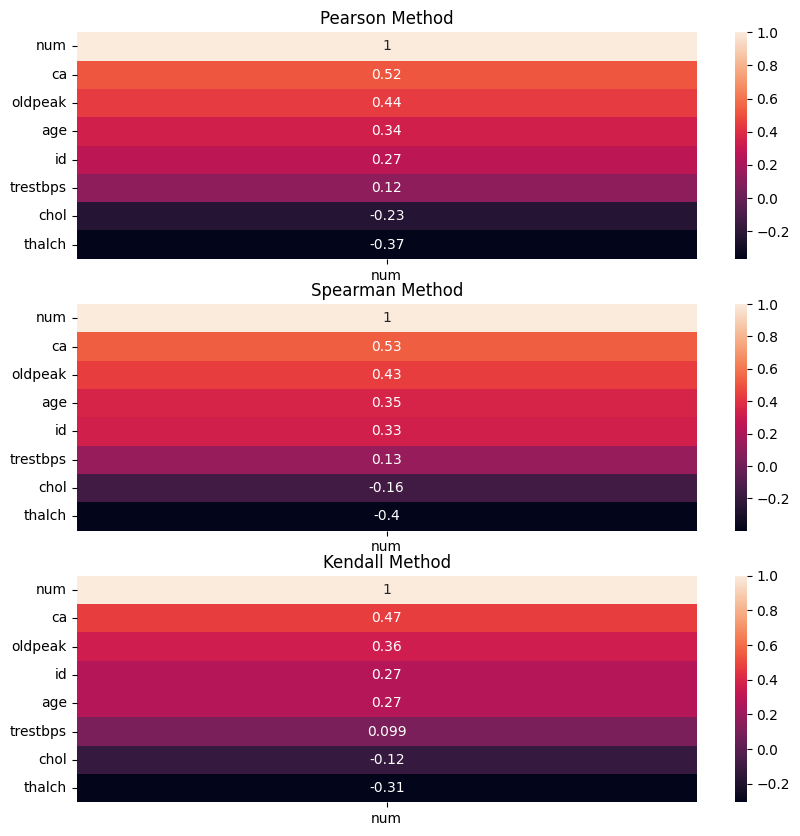

In [841]:
fig, ax = plt.subplots(3,1, figsize=(10, 10))
corr1 = numerical_data.corr('pearson')[['num']].sort_values(by='num', ascending=False)
corr2 = numerical_data.corr('spearman')[['num']].sort_values(by='num', ascending=False)
corr3 = numerical_data.corr('kendall')[['num']].sort_values(by='num', ascending=False)

ax[0].set_title('Pearson Method')
ax[1].set_title('Spearman Method')
ax[2].set_title('Kendall Method')

sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)

plt.show()

# 4. Dataset Pre-Processing

In [842]:
df = dataset.copy()

In [843]:
print("Missing values before preprocessing:")
print(df.isnull().sum())

Missing values before preprocessing:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


### Outlier Removal

In [844]:
# Recompute column lists on the current df before capping
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

before_stats = df[numeric_cols].describe()
print("\nBefore capping:")
print(before_stats)

for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    print(f"\n{col}: lower={lower:.2f}, upper={upper:.2f}")
    df[col] = df[col].clip(lower, upper)

after_stats = df[numeric_cols].describe()
print("\nAfter capping:")
print(after_stats)


Numeric columns: ['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']
Categorical columns: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

Before capping:
               id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.000000  890.000000  865.000000  858.000000   
mean   460.500000   53.510870  132.132404  199.130337  137.545665    0.878788   
std    265.725422    9.424685   19.066070  110.780810   25.926276    1.091226   
min      1.000000   28.000000    0.000000    0.000000   60.000000   -2.600000   
25%    230.750000   47.000000  120.000000  175.000000  120.000000    0.000000   
50%    460.500000   54.000000  130.000000  223.000000  140.000000    0.500000   
75%    690.250000   60.000000  140.000000  268.000000  157.000000    1.500000   
max    920.000000   77.000000  200.000000  603.000000  202.000000    6.200000   

               ca         num  
count  309.000000  920.000000  
mean     0.676

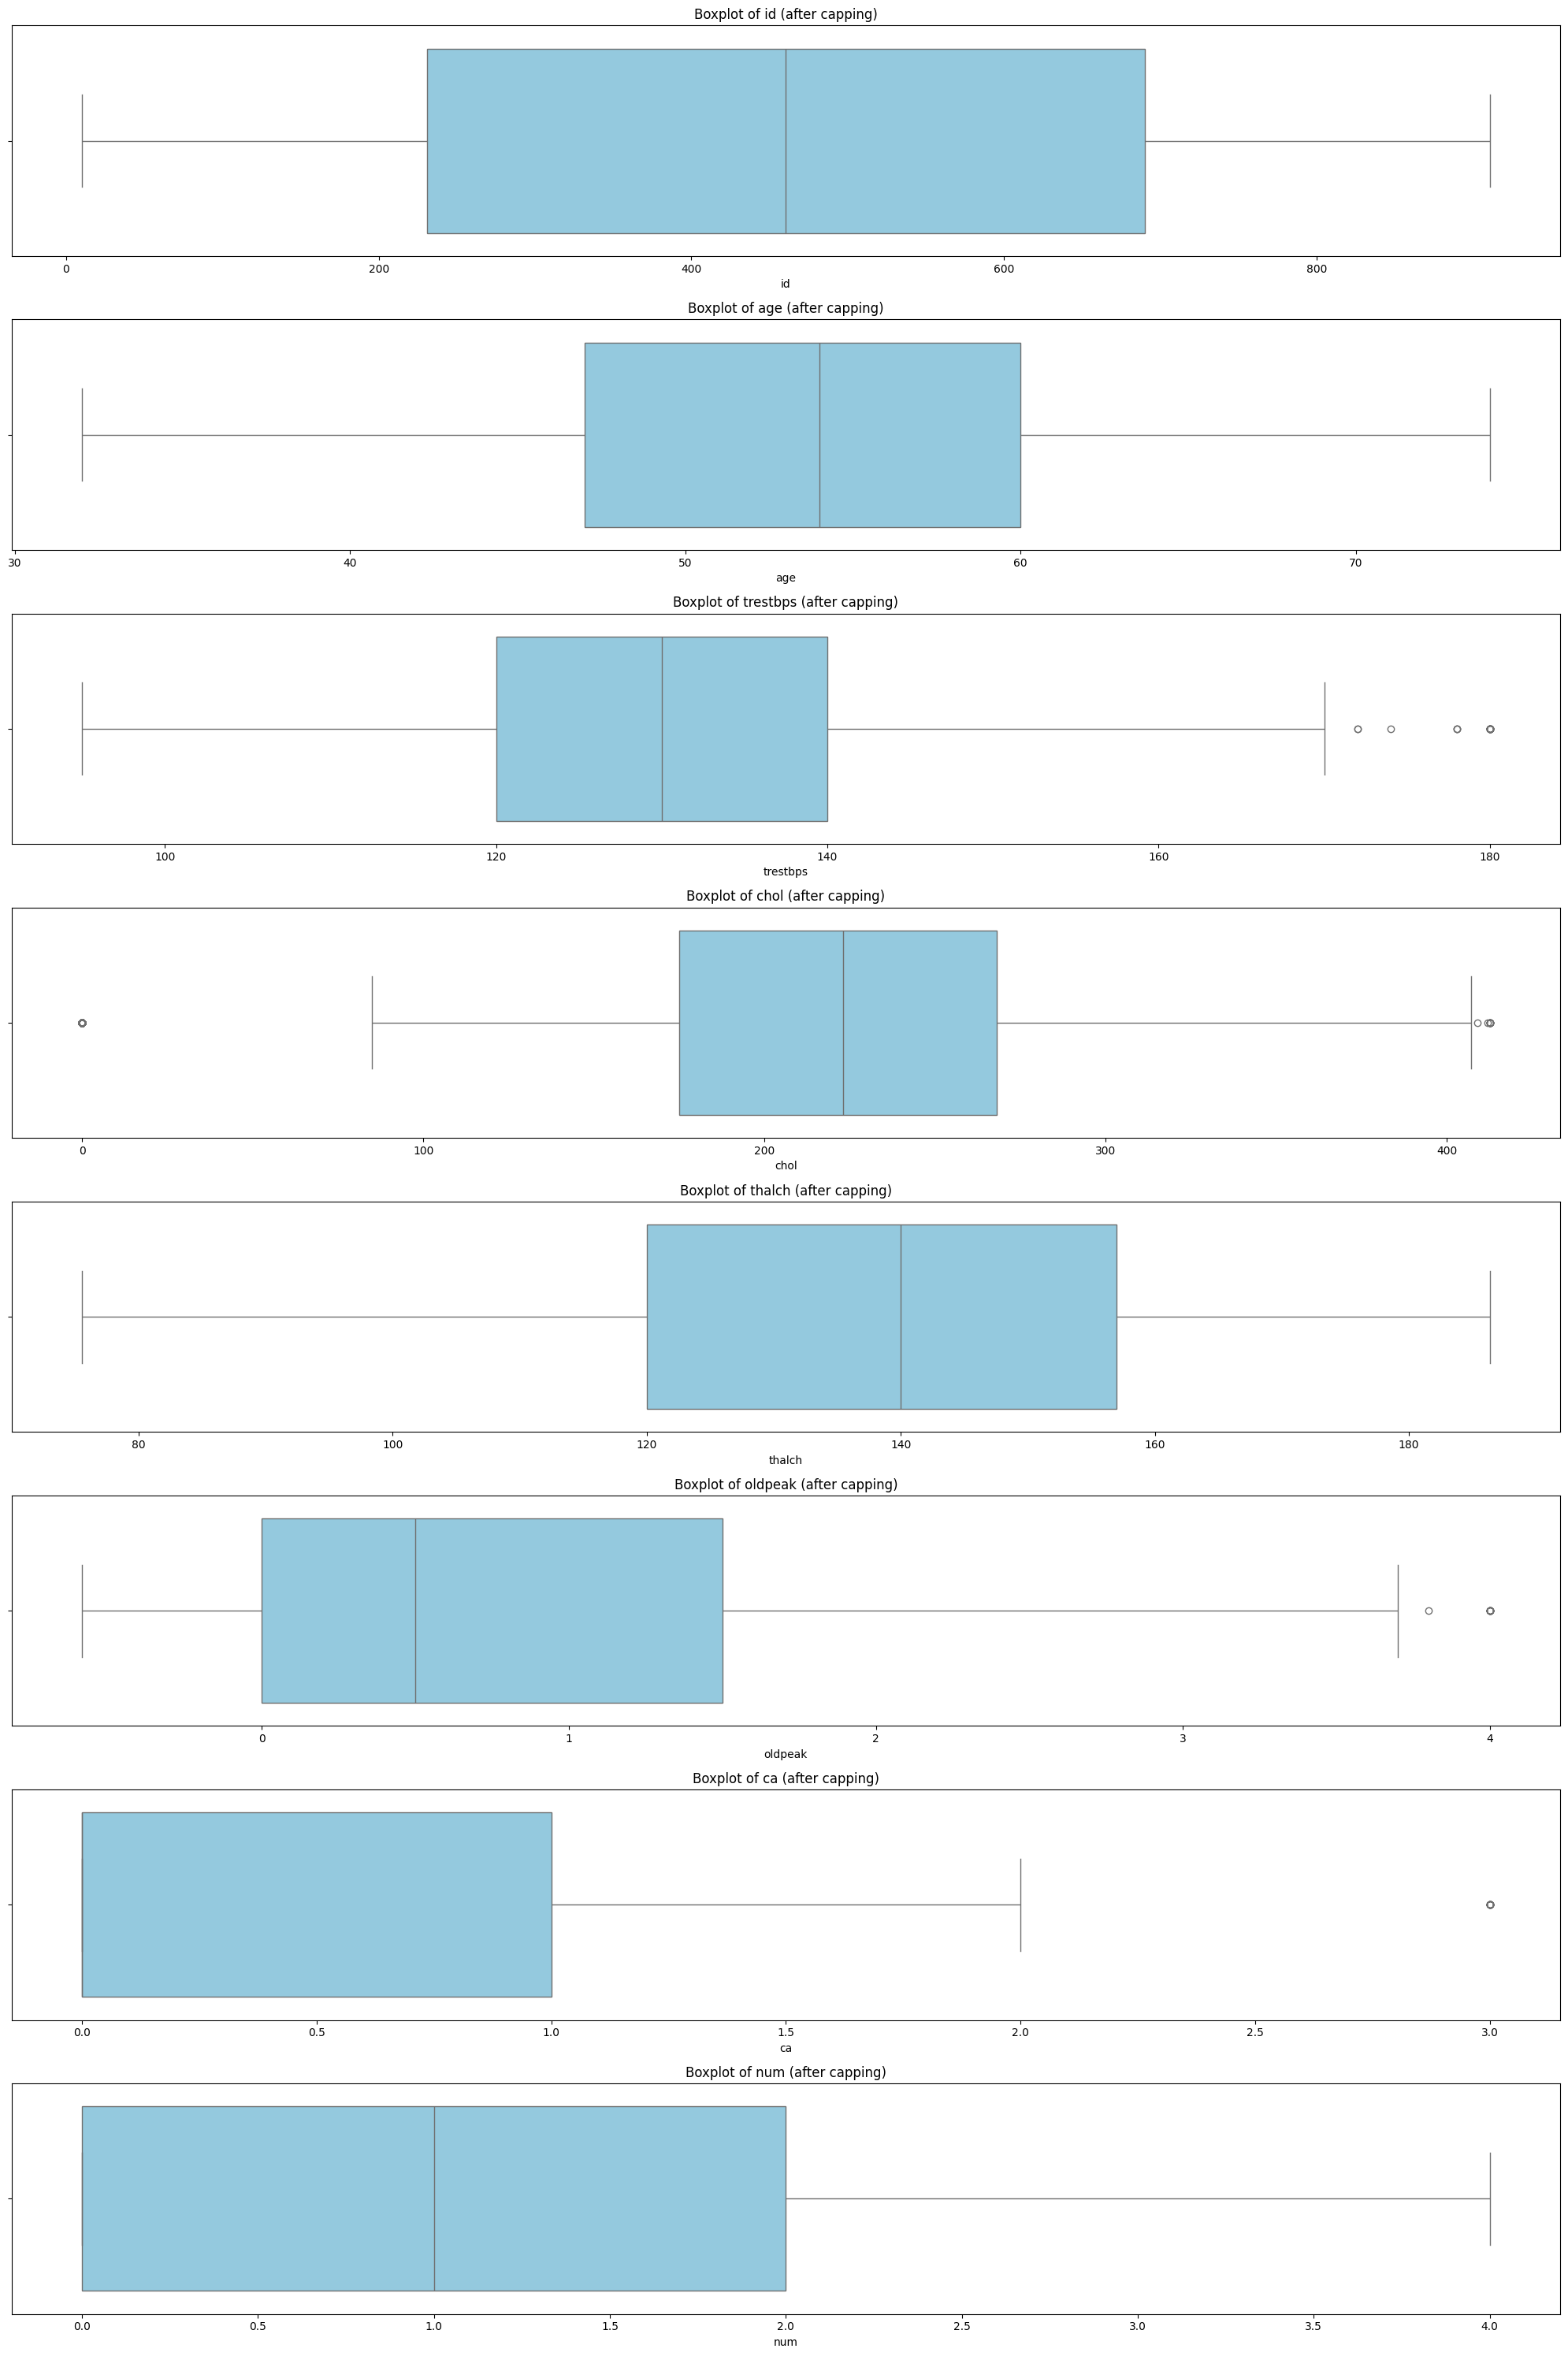

In [845]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 30))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col} (after capping)', fontsize=12)
    plt.tight_layout()

plt.show()


### Dropping Features

In [846]:
df = df.drop(columns=['ca', 'id', 'dataset'])

### Imputation

In [847]:
def impute_features(dataframe, columns):
    for col in columns:
        if dataframe[col].dtype in ['int64', 'float64']:
            strategy = 'median'
        else:
            strategy = 'most_frequent'
        imputer = SimpleImputer(strategy=strategy)
        dataframe[[col]] = imputer.fit_transform(dataframe[[col]])
    return dataframe

impute_targets = ['trestbps', 'chol', 'thalch', 'oldpeak', 'thal', 'restecg', 'slope']
df = impute_features(df, impute_targets)

### Categorical Encoding

In [848]:
# For boolean columns
bool_map = {'TRUE': True, 'FALSE': False}
df['fbs'] = df['fbs'].map(bool_map).astype(bool)
df['exang'] = df['exang'].map(bool_map).astype(bool)

In [849]:
# For non-boolean categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['fbs', 'exang']]

if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

### Target Variable Modification

In [850]:
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

### Imbalance Check

In [851]:
X = df.drop(columns=['num'])
y = (df['num'] > 0).astype(int)
numeric_cols_model = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\nClass Distribution:")
print(y.value_counts())


Class Distribution:
num
1    509
0    411
Name: count, dtype: int64


In [852]:
print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
age                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
num                         0
sex_Female                  0
sex_Male                    0
cp_asymptomatic             0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_lv hypertrophy      0
restecg_normal              0
restecg_st-t abnormality    0
slope_downsloping           0
slope_flat                  0
slope_upsloping             0
thal_fixed defect           0
thal_normal                 0
thal_reversable defect      0
dtype: int64


### Correlation Matrix

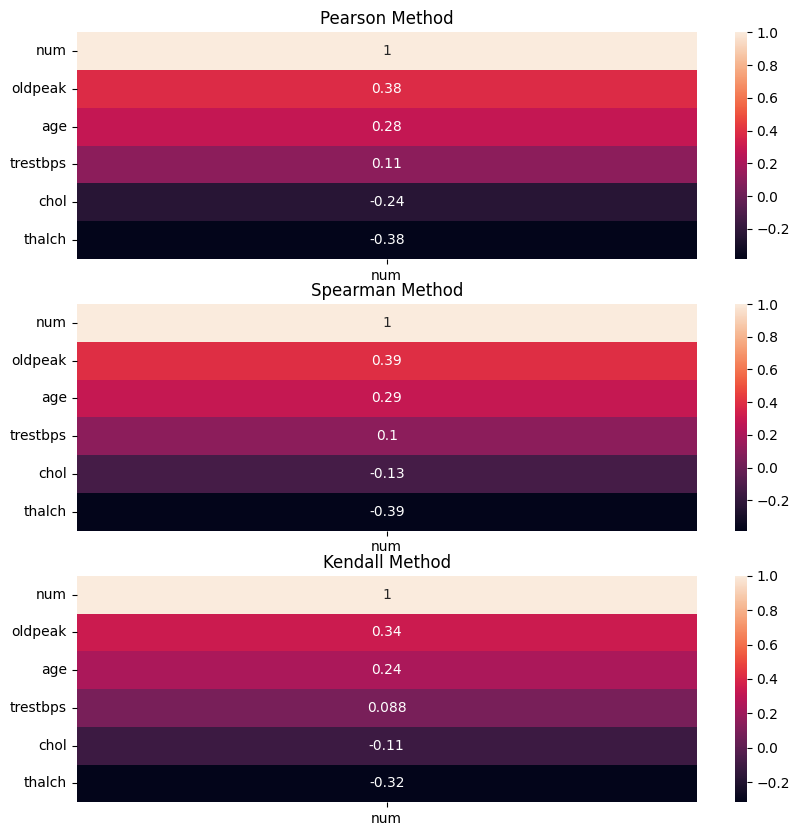

In [853]:
numerical_data = df.select_dtypes(include='number')

fig, ax = plt.subplots(3,1, figsize=(10, 10))
corr1 = numerical_data.corr('pearson')[['num']].sort_values(by='num', ascending=False)
corr2 = numerical_data.corr('spearman')[['num']].sort_values(by='num', ascending=False)
corr3 = numerical_data.corr('kendall')[['num']].sort_values(by='num', ascending=False)

ax[0].set_title('Pearson Method')
ax[1].set_title('Spearman Method')
ax[2].set_title('Kendall Method')

sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)
plt.show()

### Data Splitting

In [854]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

print(X_train.shape)
print(X_test.shape)

(644, 22)
(276, 22)


### Feature Scaling

StandardScaler normalizes features to have mean=0 and std=1, which is essential for:

1. **Distance-based algorithms** (KNN, K-Means): Features with larger scales (e.g., `chol` ranges 0-600) would dominate distance calculations over smaller-scale features (e.g., `age` ranges 29-77).

2. **Gradient-based optimization** (Logistic Regression, Neural Networks): Features on different scales cause uneven gradient magnitudes, leading to slow convergence and suboptimal solutions.

3. **Model comparability**: Ensures all models operate on the same feature representation for fair comparison.

**Why applied AFTER train-test split:**
Fitting the scaler on training data only prevents **data leakage** - the test set must remain truly unseen, including its statistical properties (mean, std).

In [855]:
scaler = StandardScaler()
X_train[numeric_cols_model] = scaler.fit_transform(X_train[numeric_cols_model])
X_test[numeric_cols_model] = scaler.transform(X_test[numeric_cols_model])

# 5. Model Training

## Neural Network Implementation

### Activation Function

In [856]:
class ReLU:
    # Apply activation function
    def forwardPropagation(self, inp: np.array) -> np.array:
        self.inputAct = np.maximum(0, inp)
        return self.inputAct

    # Calculate derivative of the activation function
    def backPropagation(self, delta: np.array) -> np.array:
        return delta * np.where(self.inputAct > 0, 1, 0)


class Sigmoid:
    # Apply activation function
    def forwardPropagation(self, inp: np.array) -> np.array:
        self.output = 1 / (1 + np.exp(-inp))
        return self.output

    # Calculate derivative of the activation function
    def backPropagation(self, delta: np.array) -> np.array:
        return delta * self.output * (1 - self.output)

### Loss Function

In [857]:
class MeanSquareError:
    def loss(self, Y: np.array, y:np.array) -> np.array:
        self.Y = Y
        self.y = y
        return np.absolute((Y - y) ** 2).sum() / y.shape[0]

    # Calculate derivative of the loss function
    def deriv(self) -> np.array:
        return (self.Y - self.y) / self.y.shape[0]


class BinaryCrossEntropy:
    def loss(self, Y: np.array, y: np.array) -> np.array:
        self.Y = Y
        self.y = y
        eps = 1e-12
        Y_clipped = np.clip(self.Y, eps, 1 - eps)
        return (- (self.y * np.log(Y_clipped) + (1 - self.y) * np.log(1 - Y_clipped))).mean()

    # Calculate derivative of the loss function
    def deriv(self) -> np.array:
        # With sigmoid output layer, the BCE gradient simplifies to (Y - y) / m
        return (self.Y - self.y) / self.y.shape[0]

### Optimizer

In [858]:
class GradientDescent:
    def __init__(self, learningRate) -> None:
        self.learningRate = learningRate

    # Calculate gradients
    def gradients(self, gradients) -> np.array:
        return self.learningRate * gradients

### Necessary Functions

In [859]:
def getActivationFunction(activation: str) -> object:
    if activation == "RELU":
        return ReLU
    if activation == "SIGMOID":
        return Sigmoid
    raise Exception("Cannot find the activation function.")


def getLossFunction(loss: str) -> object:
    if loss == "MSE":
        return MeanSquareError
    if loss == "BCE":
        return BinaryCrossEntropy
    raise Exception("Cannot find the loss function.")


def getOptimizer(optimizer: str) -> object:
    if optimizer == "GD":
        return GradientDescent
    raise Exception("Cannot find the optimizer.")

### Single Layer of Neurons

In [860]:
class NeuronLayer:
    def __init__(self, inputNeurons, outputNeurons, activation, biasFlag = True, randomState = 42) -> None:
        np.random.seed(randomState)
        # set variables
        self.inputNeurons = inputNeurons
        self.outputNeurons = outputNeurons
        self.biasFlag = biasFlag

        # get activation
        self.activation = getActivationFunction(activation)()

        # initiate parameters
        self.weights = self.__initParameters((self.inputNeurons, self.outputNeurons))
        self.bias = self.__initParameters((1, self.outputNeurons))

    # Parameter initializer
    def __initParameters(self, dimension: tuple) -> np.array:
        return np.random.uniform(-np.sqrt(2/(dimension[0] + dimension[1])), np.sqrt(2/(dimension[0] + dimension[1])),size = (dimension[0], dimension[1]))

    def build(self, optimizer, learningRate) -> None:
        self.learningRate = learningRate
        self.optimizer = getOptimizer(optimizer)(learningRate)

    # Apply forward propagation
    def forwardPropagation(self, X: np.array) -> np.array:
        self.X = X

        # Calculate weighted sum
        self.output = np.dot(self.X, self.weights) + (self.biasFlag * self.bias)
        # Apply activation function
        self.output = self.activation.forwardPropagation(self.output)

        return self.output

    # Apply backpropagation
    def backPropagation(self, upstreamGradient: np.array) -> np.array:
        # Calculate activation gradients
        delta = self.activation.backPropagation(upstreamGradient)

        # Calculate parameter gradients
        weightGrad = np.dot(self.X.T, delta) / self.X.shape[0]
        biasGrad = np.dot(np.ones((1, self.X.shape[0])), delta) /  self.X.shape[0]

        # Update parameters
        self.weights -= self.optimizer.gradients(weightGrad)
        self.bias -= self.optimizer.gradients(biasGrad)

        # Calculate downstream gradients
        downstreamGradient = np.dot(delta, self.weights.T) / self.X.shape[0]

        return downstreamGradient

### Model

In [861]:
class Model:
    # Create mini-batches
    def __createBatch(self, X: np.array, Y: np.array, batchSize: int) -> tuple:
        miniX, miniY = np.array([X[:batchSize]]), np.array([Y[:batchSize]])

        for idx in range(1, X.shape[0] // batchSize):
            miniX = np.append(miniX, np.array([X[idx * batchSize : (idx + 1) * batchSize]]), axis = 0)
            miniY = np.append(miniY, np.array([Y[idx * batchSize : (idx + 1) * batchSize]]), axis = 0)

        return miniX, miniY

    # Apply forward propagation over the model
    def __forwardPropagation(self, X: np.array) -> np.array:
        output = X
        for layer in self.layers:
            output = layer.forwardPropagation(output)
        return output

    # Apply backpropagation over the model
    def __backPropagation(self, Y: np.array) -> None:
        gradient = Y
        for layer in self.layers[::-1]:
            gradient = layer.backPropagation(gradient)

    def layers(self, layers: list) -> None:
        self.layers = layers

    # Compile the model
    def compile(self, loss, optimizer, learningRate) -> None:
        self.loss = getLossFunction(loss)()
        for layer in self.layers[::-1]:
            layer.build(optimizer, learningRate)

    # Predict the output
    def predict(self, X: np.array) -> np.array:
        return self.__forwardPropagation(X)

    # Evaluate the model
    def evaluate(self, X: np.array, Y: np.array) -> np.array:
        output = self.predict(X)
        return self.loss.loss(output, Y)

    # Train the model
    def fit(self, X: np.array, Y: np.array, epochs: int, batchSize = None) -> np.array:
        # Create mini-batch
        batchSize = (batchSize if batchSize else X.shape[0])
        self.X, self.Y = self.__createBatch(X, Y, batchSize)

        self.error = np.array([])
        # Run epoch
        for epoch in range(epochs):
            epochError = np.array([])

            # Iterate over mini-batches
            for idx in range(self.X.shape[0]):
                epochError = np.append(epochError, self.loss.loss(self.__forwardPropagation(self.X[idx]), self.Y[idx]))
                self.__backPropagation(self.loss.deriv())

            # Print epoch information
            epochError /= epochError.shape[0]
            self.error = np.append(self.error, epochError.sum() / epochError.shape[0])
            print("Epoch:", epoch + 1, "Error:", round(epochError[0], 2))

        return self.error

### Load Dataset

In [862]:
X_train_nn = np.asarray(X_train, dtype=np.float64)
X_test_nn = np.asarray(X_test, dtype=np.float64)
y_train_nn = y_train.values.reshape(-1, 1).astype(np.float64)
y_test_nn = y_test.values.reshape(-1, 1).astype(np.float64)

print(f"Neural Network training data shape: {X_train_nn.shape}")
print(f"Neural Network training labels shape: {y_train_nn.shape}")

model = Model()
model.layers = [
    NeuronLayer(X_train_nn.shape[1], 64, "RELU"),
    NeuronLayer(64, 32, "RELU"),
    NeuronLayer(32, 1, "SIGMOID")
]
model.compile(loss="BCE", optimizer="GD", learningRate=0.1)

print("Training Neural Network...")
training_error = model.fit(X_train_nn, y_train_nn, epochs=100, batchSize=32)

Neural Network training data shape: (644, 22)
Neural Network training labels shape: (644, 1)
Training Neural Network...
Epoch: 1 Error: 0.04
Epoch: 2 Error: 0.04
Epoch: 3 Error: 0.04
Epoch: 4 Error: 0.04
Epoch: 5 Error: 0.04
Epoch: 6 Error: 0.04
Epoch: 7 Error: 0.04
Epoch: 8 Error: 0.04
Epoch: 9 Error: 0.04
Epoch: 10 Error: 0.04
Epoch: 11 Error: 0.04
Epoch: 12 Error: 0.04
Epoch: 13 Error: 0.04
Epoch: 14 Error: 0.04
Epoch: 15 Error: 0.04
Epoch: 16 Error: 0.04
Epoch: 17 Error: 0.04
Epoch: 18 Error: 0.04
Epoch: 19 Error: 0.04
Epoch: 20 Error: 0.04
Epoch: 21 Error: 0.04
Epoch: 22 Error: 0.04
Epoch: 23 Error: 0.04
Epoch: 24 Error: 0.04
Epoch: 25 Error: 0.04
Epoch: 26 Error: 0.04
Epoch: 27 Error: 0.04
Epoch: 28 Error: 0.04
Epoch: 29 Error: 0.04
Epoch: 30 Error: 0.04
Epoch: 31 Error: 0.04
Epoch: 32 Error: 0.04
Epoch: 33 Error: 0.04
Epoch: 34 Error: 0.04
Epoch: 35 Error: 0.04
Epoch: 36 Error: 0.04
Epoch: 37 Error: 0.04
Epoch: 38 Error: 0.04
Epoch: 39 Error: 0.04
Epoch: 40 Error: 0.04
Epoch: 41

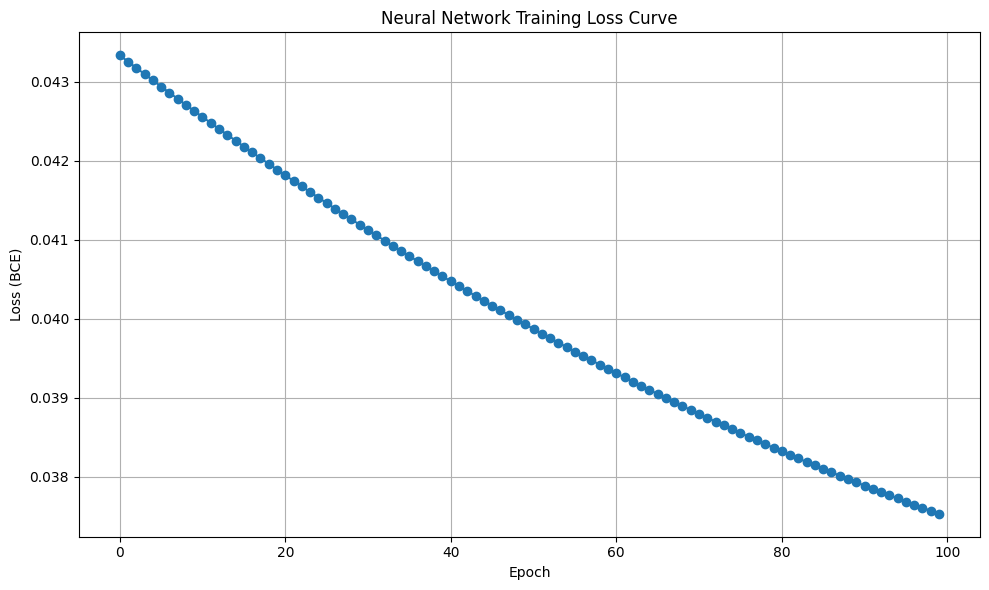

Neural Network Test BCE: 0.7497


In [863]:
plt.figure(figsize=(10, 6))
plt.plot(training_error, marker='o')
plt.title("Neural Network Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (BCE)")
plt.grid(True)
plt.tight_layout()
plt.show()

test_error = model.evaluate(X_test_nn, y_test_nn)
print(f"Neural Network Test BCE: {test_error:.4f}")

## Other Models

Our problem is a classification problem, as such, we have chosen Logistic Regression, Decision Tree, KNN, and Random Forest for learning.

---------------------------------------------------------------------------
Logistic Regression:
  Accuracy:  0.8152
  Precision: 0.8269
  Recall:    0.8431
  F1-Score:  0.8350
  ROC-AUC:   0.8901


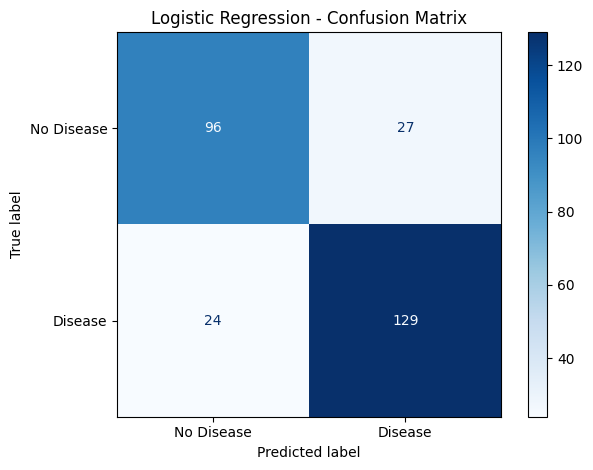

---------------------------------------------------------------------------
KNN (k=5):
  Accuracy:  0.8261
  Precision: 0.8344
  Recall:    0.8562
  F1-Score:  0.8452
  ROC-AUC:   0.8844


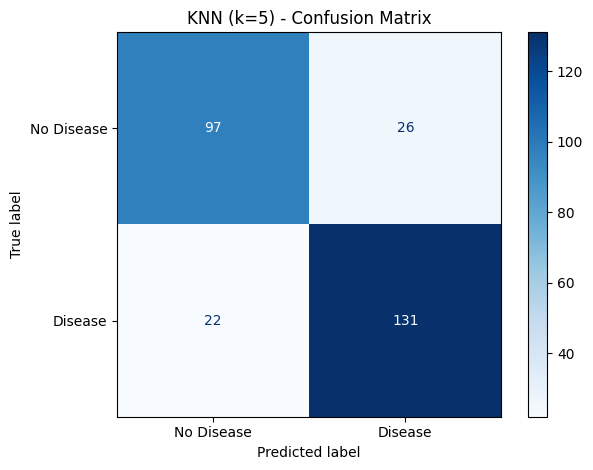

---------------------------------------------------------------------------
Random Forest:
  Accuracy:  0.8261
  Precision: 0.8387
  Recall:    0.8497
  F1-Score:  0.8442
  ROC-AUC:   0.8975


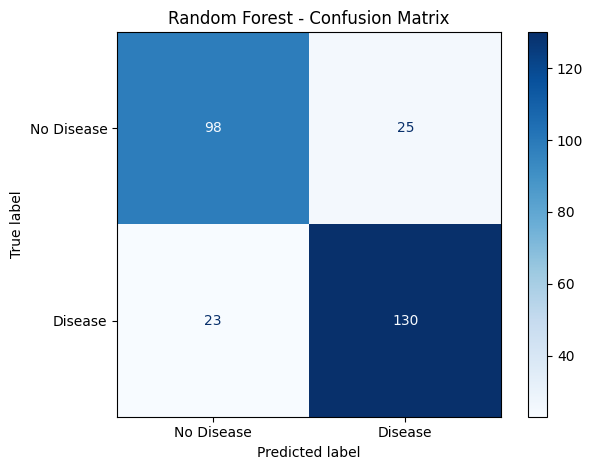

---------------------------------------------------------------------------
Neural Network (MLP):
  Accuracy:  0.8297
  Precision: 0.8313
  Recall:    0.8693
  F1-Score:  0.8498
  ROC-AUC:   0.8978


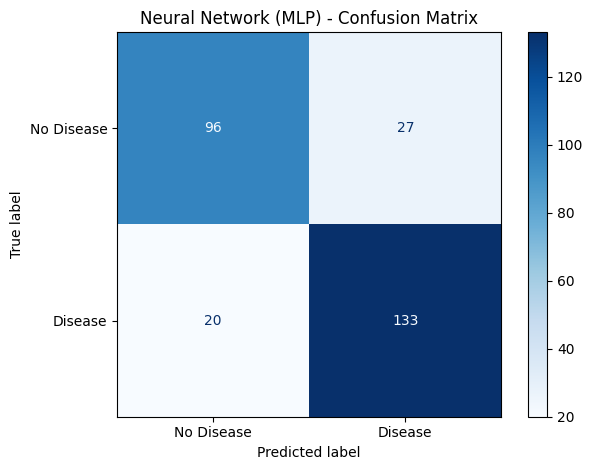

In [864]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Neural Network (MLP)': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.01,
        batch_size=32,
        learning_rate="adaptive",
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Store results
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

    # Print Metrics
    print("-" * 75)
    print(f"{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease']).plot(cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.tight_layout()
    plt.show()

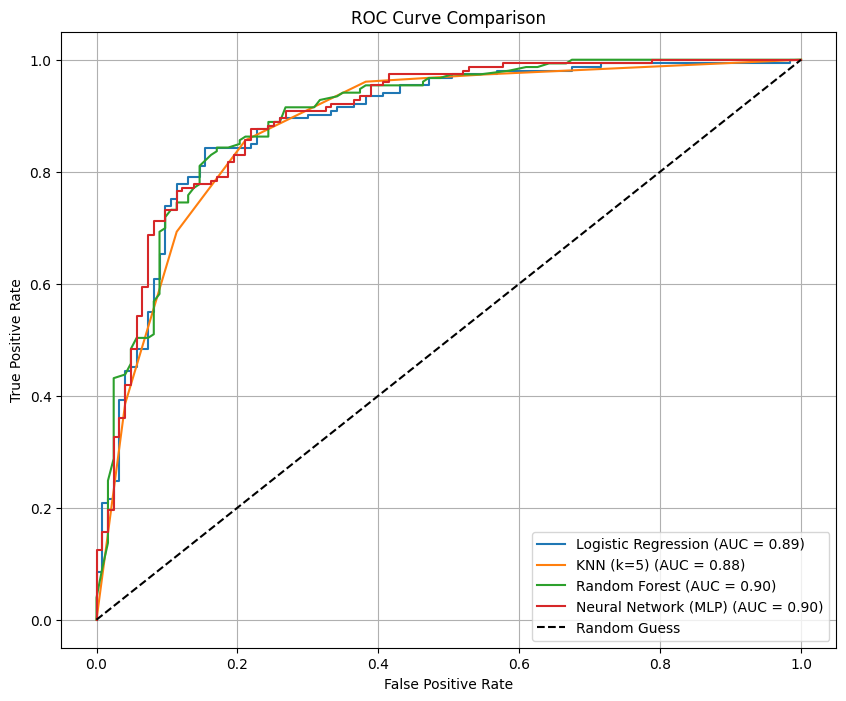

In [865]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Fit
    model.fit(X_train, y_train)

    # Predict probabilities for class 1 (survived)
    y_probs = model.predict_proba(X_test)[:, 1]

    # ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot random line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Final plot setup
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid()
plt.show()

## K-Means Clustering (Unsupervised)

In [866]:
X_scaled = X.copy()
X_scaled[numeric_cols_model] = StandardScaler().fit_transform(X_scaled[numeric_cols_model])

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled.values)

sil = silhouette_score(X_scaled.values, cluster_labels)
ari = adjusted_rand_score(y, cluster_labels)

print(f"Silhouette: {sil:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")
print("Cluster vs Actual:")
print(pd.crosstab(cluster_labels, y, margins=True))

Silhouette: 0.1498
Adjusted Rand Index: 0.2406
Cluster vs Actual:
num      0    1  All
row_0               
0      312  135  447
1       99  374  473
All    411  509  920


# 6. Model Evaluation

In [ ]:
results_df = pd.DataFrame(results).T.sort_values(by='F1-Score', ascending=False)

print("\nModel Performance Comparison:")
print(results_df.round(4))

kmeans_metrics = pd.DataFrame(
    {
        'Silhouette': [sil],
        'Adjusted Rand Index': [ari]
    },
    index=['K-Means (k=2)']
)

print("\nK-Means (k=2) Metrics:")
print(kmeans_metrics.round(4))


Model Performance Comparison:
                      Accuracy  Precision  Recall  F1-Score  ROC-AUC
Neural Network (MLP)    0.8297     0.8312  0.8693    0.8498   0.8978
KNN (k=5)               0.8261     0.8344  0.8562    0.8452   0.8844
Random Forest           0.8261     0.8387  0.8497    0.8442   0.8975
Logistic Regression     0.8152     0.8269  0.8431    0.8350   0.8901


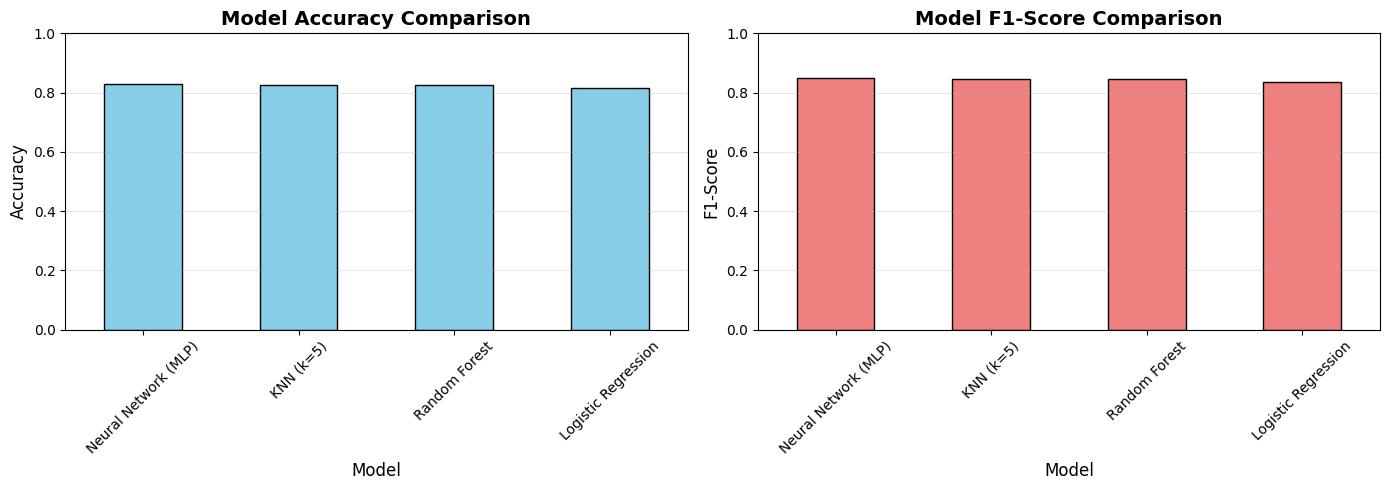

In [868]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df['Accuracy'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

results_df['F1-Score'].sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

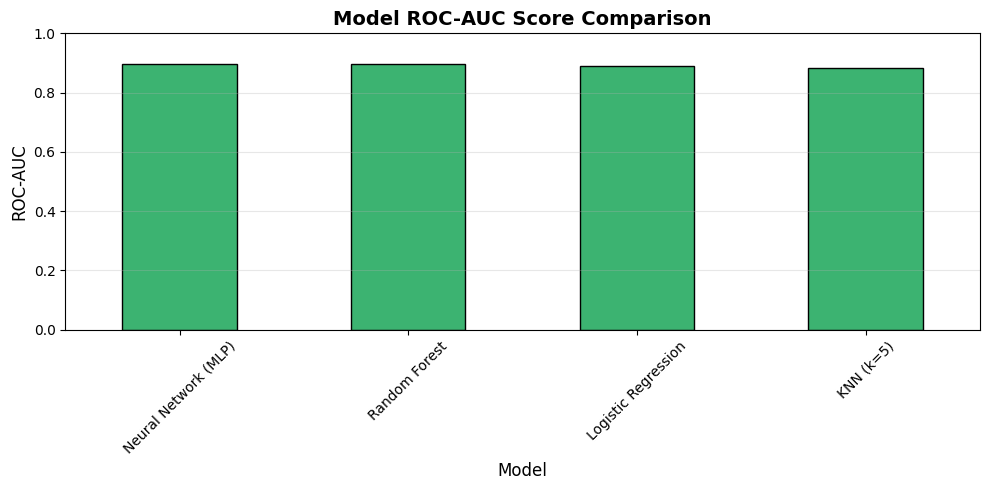

In [869]:
roc_scores = results_df['ROC-AUC'].dropna().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
roc_scores.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='black')
ax.set_title('Model ROC-AUC Score Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 7. Conclusion

In [870]:
best_model_name = results_df.index[0]
best_metrics = results_df.iloc[0]

print(f"\nBest Model: {best_model_name}")
print(f"Accuracy: {best_metrics['Accuracy']:.4f}")
print(f"Precision: {best_metrics['Precision']:.4f}")
print(f"Recall: {best_metrics['Recall']:.4f}")
print(f"F1-Score: {best_metrics['F1-Score']:.4f}")
print(f"ROC-AUC: {best_metrics['ROC-AUC']:.4f}" if not np.isnan(best_metrics['ROC-AUC']) else "ROC-AUC: N/A")


Best Model: Neural Network (MLP)
Accuracy: 0.8297
Precision: 0.8313
Recall: 0.8693
F1-Score: 0.8498
ROC-AUC: 0.8978


In [871]:
print("\nANALYSIS SUMMARY:")
print("-" * 80)
print("\n1. Feature Engineering: Dropped 'ca' column due to excessive missing values.")
print("   Categorical features (sex, cp, restecg, exang, slope, thal) were one-hot encoded.")
print("   Numeric features were standardized using StandardScaler.")
print("\n2. Target Variable: Binary classification (disease present/absent).")
print("   Class distribution shows negligible imbalance in the dataset.")
print("\n3. Model Performance:")
print(f"   - Best Supervised Model: {best_model_name} (F1-Score: {best_metrics['F1-Score']:.4f})")
# print(f"   - Neural Network Test MSE: {test_error:.4f}")
print(f"   - K-Means Silhouette Score: {sil:.4f}")
print("-" * 80)


ANALYSIS SUMMARY:
--------------------------------------------------------------------------------

1. Feature Engineering: Dropped 'ca' column due to excessive missing values.
   Categorical features (sex, cp, restecg, exang, slope, thal) were one-hot encoded.
   Numeric features were standardized using StandardScaler.

2. Target Variable: Binary classification (disease present/absent).
   Class distribution shows negligible imbalance in the dataset.

3. Model Performance:
   - Best Supervised Model: Neural Network (MLP) (F1-Score: 0.8498)
   - K-Means Silhouette Score: 0.1498
--------------------------------------------------------------------------------
